# Problem Statement: Build a Smart Mutual Fund Advisor

*On top of the Mutual Funds Report, [sourced](https://www.kaggle.com/datasets/dhavalrupapara/mutual-funds-market-dataset) from Kaggle*

---

## Objective  
Create a Gradio-based AI assistant that recommends a mutual fund investment portfolio based on the user's risk and return preferences. The app uses Retrieval-Augmented Generation (RAG) on a structured Mutual Fund product dataset, generating explainable, structured results.

---

## User App (Essential Features)

### Inputs
- **Investment Needs**: Free-form text input  
  *(e.g., “high return portfolio, only from Aditya Birla fund house”)*
  
### Output
- **Suggestion**: A natural language explanation of what's recommended and why
- **Recommended Mutual Funds**: Structured as a list containing:
  - Scheme Name
  - Fund House
---

## Developer-Facing Advanced Settings

Shown under a collapsible **LLM Settings (Advanced)** section in the UI.

### Model & Generation Settings
- **Model Selector**: *select 2 more open-source / closed-source models*
  - GPT OSS 120B (`gpt-oss-120b`)
- **Temperature Slider**: Adjustable between 0 and 2

These settings allow developers to tune how deterministic or creative the model’s responses are.

---

## Backend Setup

### Vector Store and RAG
- **Embedding Model**: Nomic Embed Text via Ollama, or other model of your choice
- **Vector Database**: ChromaDB, or other vector DB of your choice
- **RAG Workflow**:
  1. Load product catalog using `CSVLoader`
  2. Parse and clean fields into `Document` objects with metadata
  3. Generate embeddings and index documents
  4. Perform similarity search based on user preferences
  5. Use an LLM to generate structured output parsed via `PydanticOutputParser`

# Part 1: Implement the Solution

## Setup

In [226]:
import gradio as gr
import pandas as pd
import os
from dotenv import load_dotenv
from IPython.display import Image, display
from langchain_tavily import TavilySearch
from langchain_chroma import Chroma
from langchain_ollama import OllamaEmbeddings
from langchain_community.document_loaders import CSVLoader
from langchain.chat_models import init_chat_model
from langchain_openai import OpenAI
from langchain.prompts import ChatPromptTemplate
from langchain.output_parsers import PydanticOutputParser
from langchain.schema.output_parser import OutputParserException
from langchain_core.documents import Document
from pydantic import BaseModel, Field
from uuid import uuid4
from langgraph.graph import START, StateGraph, END
from typing_extensions import List, TypedDict
from langgraph.checkpoint.memory import MemorySaver

In [2]:
## TODO: Load environment variables and API Keys here

## Defining Components

### Chat Model

In [2]:
## TODO: Model name map for UI Mapping
model_name_map = {
    "GPT-OSS-120B": "openai/gpt-oss-120b"
    ## TODO: Add 2 more models here
}

model_choices = [
    "GPT-OSS-120B (Groq)"
    ## TODO: Add 2 more models here
]

In [4]:
## TODO: Model Selector
def get_llm(model_choice, temperature):
    if "Groq" in model_choice:
        return init_chat_model(model_name_map[model_choice.split(" ")[0]], model_provider="groq", temperature = temperature)
    else:
        raise ValueError("Invalid model")

### Embedding Model

In [46]:
## TODO: Create embeddings
## Use: OllamaEmbeddings with llama3.2:1b and pull the model beforehand

pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠴ pulling manifest ⠦ pulling manifest ⠧ pulling manifest ⠇ pulling manifest ⠏ pulling manifest ⠋ pulling manifest 
pulling 74701a8c35f6: 100% ▕██████████████████▏ 1.3 GB                         
pulling 966de95ca8a6: 100% ▕██████████████████▏ 1.4 KB                         
pulling fcc5a6bec9da: 100% ▕██████████████████▏ 7.7 KB                         
pulling a70ff7e570d9: 100% ▕██████████████████▏ 6.0 KB                         
pulling 4f659a1e86d7: 100% ▕██████████████████▏  485 B                         
verifying sha256 digest 
writing manifest 
success 


### Vector Store

In [50]:
## TODO: Initialize ChromaDB with a persist directory set

## Load and Preprocess Data

In [6]:
# Load and preprocess data
loader = CSVLoader(file_path="mutual_funds_data.csv", source_column="scheme_code")
documents_raw = loader.load()

In [7]:
# Convert page_content string to dict and build metadata
documents = []
for doc in documents_raw:
    try:
        row_data = dict(
            line.split(":", 1) for line in doc.page_content.split("\n") if ":" in line
        )
        row_data = {k.strip(): v.strip() for k, v in row_data.items()}

        ## TODO: Keep Scheme Name, Fund House, Scheme Type, Scheme Category, Net Asset Value and Date in content
        page_text = 

        ## TODO: Keep Scheme Type, Scheme Category in metadata
        metadata = 

        documents.append(Document(page_content=page_text, metadata=metadata))

    except Exception as e:
        print("Skipping row due to error:", e)

In [8]:
len(documents)

35559

In [10]:
print(documents[0].page_content)


        Scheme Name: Grindlays Super Saver Income Fund-GSSIF-Half Yearly Dividend | 
        Fund House: Standard Chartered Mutual Fund | 
        Scheme Type: Open Ended Schemes | 
        Scheme Category: Income | 
        Net Asset Value: 10.7205 | 
        Date: 29-05-2008
        


In [11]:
len(documents)

35559

## Store in Vector DB

In [5]:
## Store in Chroma - 1000 rows only for quicker processing - and make sure to add UUIDs
## TODO: Add UUIDs
uuids =

## TODO: Add documents


## Initializing for RAG

### Initialize Retriever

In [6]:
## TODO: Initializer Retriever below


### Define Pydantic Schema

In [279]:
## TODO: Define Pydantic schema with type and description
class MutualFund(BaseModel):
    scheme_name: 
    fund_house:
    scheme_type:
    scheme_category:
    
class MutualFundOutput(BaseModel):
    reasoning:
    schemes:

parser = PydanticOutputParser(pydantic_object=MutualFundOutput)

### Define Prompt

In [7]:
## TODO: Use ChatPromptTemplate.from_template with fields: preferences, context, format_instructions. 
## Make sure no two selected mutual fund schemes fall under the same fund house AND scheme type.

template = 

## Creating RAG Pipeline

### Test RAG Pipeline Manually

In [288]:
preference = "I want a low risk investment portfolio."
context_docs =  ## TODO: Retrieve relevant funds
relevant_text = ## TODO: Joining the funds
llm = ## TODO: Get LLM
chain = ## TODO: Create a Runnable Sequence with 3 Runnables - template, LLM and Output Parser
input_dict = ## TODO: Create dictionary with preferences, context and format_instructions
chain.invoke ## TODO: Invoke chain and the output of this command should be a dictionary

{'reasoning': "The selected mutual funds are chosen based on the user's preference for a low-risk investment portfolio. Each fund is from a different fund house and scheme type, ensuring diversification while maintaining a focus on low-risk options. The funds selected are primarily in the income category, which typically offers lower volatility and more stable returns compared to equity funds.",
 'schemes': [{'scheme_name': 'Tata Liquid High Investment Plan - Monthly',
   'fund_house': 'Tata Mutual Fund',
   'scheme_type': 'Open Ended Schemes',
   'scheme_category': 'Income'},
  {'scheme_name': 'Kotak Bond-Deposit-Growth',
   'fund_house': 'Kotak Mahindra Mutual Fund',
   'scheme_type': '120471;INF192K01EA7;-;JM Short Term Fund',
   'scheme_category': 'Direct'},
  {'scheme_name': 'CANGROWTH PLUS',
   'fund_house': 'Canara Robeco Mutual Fund',
   'scheme_type': 'Open Ended Schemes',
   'scheme_category': 'Income'}]}

### Define RAG Pipeline Function

In [289]:
# RAG pipeline
def generate_portfolio(model_choice, user_input):
    context_docs =  ## TODO: Retrieving relevant funds
    relevant_funds =  ## TODO: Joining the funds
    llm = ## TODO: Get the LLM
    
    #Invoking
    chain = ## TODO: Create a Runnable Sequence with 2 Runnables - template and LLM
    output = ## TODO: Invoke the Runnable Sequence with the preferences, context and format instructions

    #Exception Handling
    try:
        result = parser.parse(output.content)
    except OutputParserException:
        return "Could not parse output.", None
    return result

## User Interface

In [290]:
def gradio_interface(preferences, model_choice, temperature):
    user_input = {
        "preferences": preferences,
        "model_choice": model_choice,
        "temperature": temperature,
    }
    result = generate_portfolio(model_choice, user_input)
    if not result or isinstance(result, str):
        return result, []
    if isinstance(result, tuple):
        explanation, _ = result
        return explanation, []
    # Build a plain text list of scheme recommendations
    list_output = "\n".join(
        f"🔹 {scheme.scheme_name} | Fund House: {scheme.fund_house}"
        for scheme in result.schemes
    )

    return result.reasoning, list_output

In [291]:
# Gradio Blocks layout
with gr.Blocks(title="Smart Mutual Fund Advisor") as demo:
    gr.Markdown("## Smart Mutual Fund Advisor")
    gr.Markdown("Enter your investment preferences and let AI suggest a portfolio!")

    with gr.Row():
        preferences_input = gr.Textbox(
            label="Describe your investment needs",
            placeholder="e.g., high return portfolio, only from Aditya Birla fund house",
            lines=2
        )

    with gr.Accordion("LLM Settings (Advanced)", open=False):
        model_dropdown = gr.Dropdown(
            label="Model",
            choices=model_choices,
            value=model_choices[0]
        )
        temperature_slider = gr.Slider(
            minimum=0.0, maximum=2, value=0.7, step=0.1,
            label="Temperature"
        )

    run_button = gr.Button("Generate Portfolio")

    with gr.Row():
        reasoning_output = gr.Textbox(label="Remarks", lines=2)

    with gr.Row():
        fund_list_output = gr.Textbox(label="Recommended Mutual Funds", lines=10)

    run_button.click(
        fn=gradio_interface,
        inputs=[preferences_input, model_dropdown, temperature_slider],
        outputs=[reasoning_output, fund_list_output]
    )

In [292]:
demo.launch(inline=True)

* Running on local URL:  http://127.0.0.1:7900
* To create a public link, set `share=True` in `launch()`.


# Part 2: Implement the RAG pipeline in LangGraph

## Creating Graph

### Define State Class

In [293]:
## TODO: Define State class with preferences, context and answer keys
class State():
    preferences:
    context:
    answer:

### Define Nodes

In [294]:
## TODO: Define retrieve node
def retrieve():
    relevant_funds = ## TODO: Retrieving relevant mutual funds
    return ## TODO: Return the relevant parts of the state: context only

In [295]:
## TODO: Define generate node
def generate():
    relevant_funds_str = ## TODO: Joining the mutual funds
        
    chain = ## TODO: Create a Runnable Sequence with 2 Runnables - template and llm_graph (different variable that's defined later)
    output = ## TODO: Invoke the Runnable Sequence with the preferences, context and format instructions

    #Exception Handling for Output Parser
    try:
        result = parser.parse(output.content)
    except OutputParserException:
        return "Could not parse output.", None
        
    return ## TODO: Return the relevant parts of the state: answer only

### Build and Compile Graph

In [296]:
## TODO: Build the graph with 2 nodes and 3 edges
graph_builder = ## TODO: To add

graph_builder.add_node() ## TODO: To add
graph_builder.add_node() ## TODO: To add

graph_builder.add_edge() ## TODO: To add
graph_builder.add_edge() ## TODO: To add
graph_builder.add_edge() ## TODO: To add

In [297]:
#Compile graph
graph = graph_builder.compile()

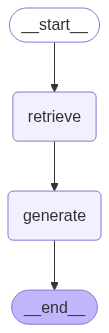

In [298]:
#Visualize graph
display(Image(graph.get_graph().draw_mermaid_png()))

### Test Manually

In [299]:
preferences = "I want a low risk investment portfolio."
llm_graph = ## TODO: Get LLM
result = ## TODO: Invoke the graph
print(f'Context: {result["context"]}\n\n')
print(f'Answer: {result["answer"]}')

Context: [Document(id='bcde018f-5ee3-41db-8d8a-9e4ca9be7b30', metadata={'Scheme Type': 'Open Ended Schemes', 'Scheme Category': 'Income'}, page_content='\n        Scheme Name: Tata Liquid High Investment Plan - Monthly | \n        Fund House: Tata Mutual Fund | \n        Scheme Type: Open Ended Schemes | \n        Scheme Category: Income | \n        Net Asset Value: 0 | \n        Date: 01-04-2017\n        '), Document(id='74bfa6fa-1bb6-468e-bcfd-00e2aafe2c03', metadata={'Scheme Category': 'Direct', 'Scheme Type': '120471;INF192K01EA7;-;JM Short Term Fund'}, page_content='\n        Scheme Name: Kotak Bond-Deposit-Growth | \n        Fund House: Kotak Mahindra Mutual Fund | \n        Scheme Type: 120471;INF192K01EA7;-;JM Short Term Fund | \n        Scheme Category: Direct | \n        Net Asset Value: 42.9354 | \n        Date: 21-10-2016\n        '), Document(id='34dc77ef-d524-47f8-a9cc-83ee023e8ebf', metadata={'Scheme Type': 'Open Ended Schemes', 'Scheme Category': 'Income'}, page_content

## User Interface

In [300]:
def gradio_interface(preferences, model_choice, temperature):
    user_input = {
        "preferences": preferences,
        "model_choice": model_choice,
        "temperature": temperature,
    }
    llm_graph = get_llm(user_input["model_choice"], user_input["temperature"])
    result = graph.invoke({"preferences": preferences})["answer"]
    
    if not result or isinstance(result, str):
        return result, []
    if isinstance(result, tuple):
        explanation, _ = result
        return explanation, []
    # Build a plain text list of scheme recommendations
    list_output = "\n".join(
        f"🔹 {scheme.scheme_name} | Fund House: {scheme.fund_house}"
        for scheme in result.schemes
    )

    return result.reasoning, list_output

In [301]:
# Gradio Blocks layout
with gr.Blocks(title="Smart Mutual Fund Advisor") as demo:
    gr.Markdown("## Smart Mutual Fund Advisor")
    gr.Markdown("Enter your investment preferences and let AI suggest a portfolio!")

    with gr.Row():
        preferences_input = gr.Textbox(
            label="Describe your investment needs",
            placeholder="e.g., high return portfolio, only from Aditya Birla fund house",
            lines=2
        )

    with gr.Accordion("LLM Settings (Advanced)", open=False):
        model_dropdown = gr.Dropdown(
            label="Model",
            choices=model_choices,
            value=model_choices[0]
        )
        temperature_slider = gr.Slider(
            minimum=0.0, maximum=2, value=0.7, step=0.1,
            label="Temperature"
        )

    run_button = gr.Button("Generate Portfolio")

    with gr.Row():
        reasoning_output = gr.Textbox(label="Remarks", lines=2)

    with gr.Row():
        fund_list_output = gr.Textbox(label="Recommended Mutual Funds", lines=10)

    run_button.click(
        fn=gradio_interface,
        inputs=[preferences_input, model_dropdown, temperature_slider],
        outputs=[reasoning_output, fund_list_output]
    )

In [302]:
demo.launch(inline=True)

* Running on local URL:  http://127.0.0.1:7901
* To create a public link, set `share=True` in `launch()`.
